In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [14]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df.shape

(7043, 21)

In [16]:
# Check missing values
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [18]:
# This tells you which columns contain categorical data
df.select_dtypes(include=['object', 'category']).columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

# TARGET VARIABLE EDA

In [19]:
df['Churn'].value_counts(normalize=True) * 100
# ML mein ye check karna important hai ki target variable balanced hai ya imbalanced
# Isliye baad mein sirf accuracy dekhna misleading ho sakta hai.
# Isliye baad mein hum precision, recall, F1-score aur confusion matrix bhi dekhenge

,proportion
Churn,
No,73.463013
Yes,26.536987


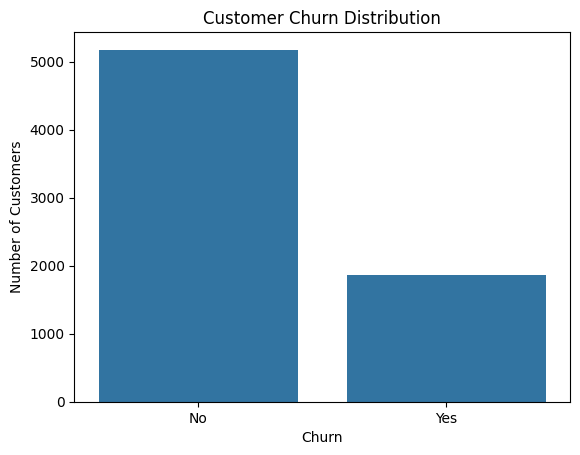

In [20]:
sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

# EDA: CATEGORICAL VARIABLES
value_counts() -->
crosstab with Churn -->
countplot-->
interpretation

customerID

In [21]:
# drop it
df['customerID'].value_counts()

,count
customerID,
3186-AJIEK,1
7590-VHVEG,1
5575-GNVDE,1
4501-VCPFK,1
6075-SLNIL,1
...,...
1452-KIOVK,1
6713-OKOMC,1
7892-POOKP,1


gender

In [22]:
df['gender'].value_counts()

,count
gender,
Male,3555
Female,3488


In [23]:
pd.crosstab(df['gender'],df['Churn'],normalize='index') * 100
# related with data but we convert into male=0, female=1 and then check their relation again

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


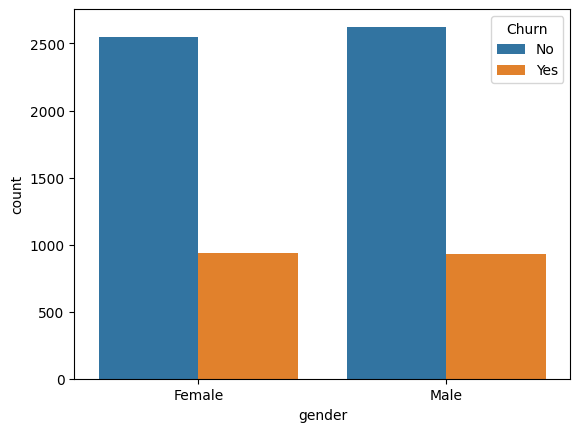

In [24]:
sns.countplot(x='gender', hue='Churn', data=df)
plt.show()

Partner

In [25]:
df['Partner'].value_counts()

,count
Partner,
No,3641
Yes,3402


In [26]:
# the number of customers in each group may differ, so comparing raw bar heights(count plot) can mislead you.
pd.crosstab(df['Partner'], df['Churn'], normalize='index') * 100


# Partner = No → 32.96% churn
# Partner = Yes → 19.66% churn

# The difference is:
# 32.96% − 19.66% = 13.30 percentage points
# So unlike gender, I wouldn't consider Partner a useless feature based on this analysis

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


<Axes: xlabel='Partner', ylabel='count'>

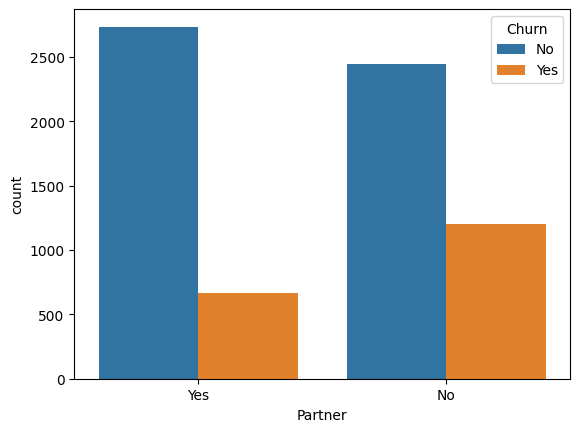

In [27]:
sns.countplot(data=df, x='Partner', hue='Churn')

Dependents

In [28]:
df['Dependents'].value_counts()

,count
Dependents,
No,4933
Yes,2110


In [29]:
pd.crosstab(df['Dependents'], df['Churn'], normalize='index') * 100
# this feature is also useful like partners

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


<Axes: xlabel='Dependents', ylabel='count'>

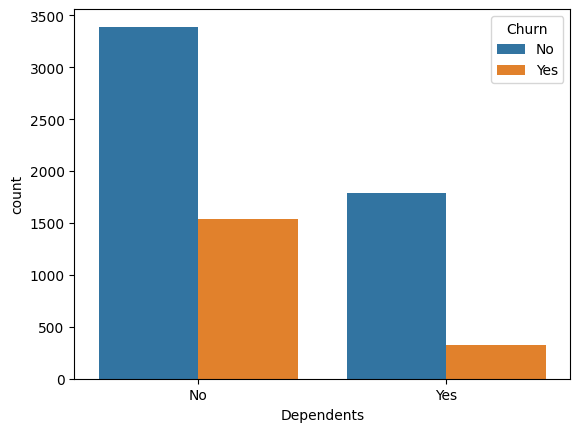

In [30]:
sns.countplot(data=df, x='Dependents', hue='Churn')

PhoneService

In [31]:
df['PhoneService'].value_counts()

,count
PhoneService,
Yes,6361
No,682


In [32]:
pd.crosstab(df['PhoneService'], df['Churn'], normalize='index')*100

# PhoneService shows a weak relationship with Churn

# No  → 24.93% churn
# Yes → 26.71% churn
# Difference → 1.78%

# Train the model with them first.
# Then remove weak features and compare validation performance.

Churn,No,Yes
PhoneService,,
No,75.073314,24.926686
Yes,73.290363,26.709637


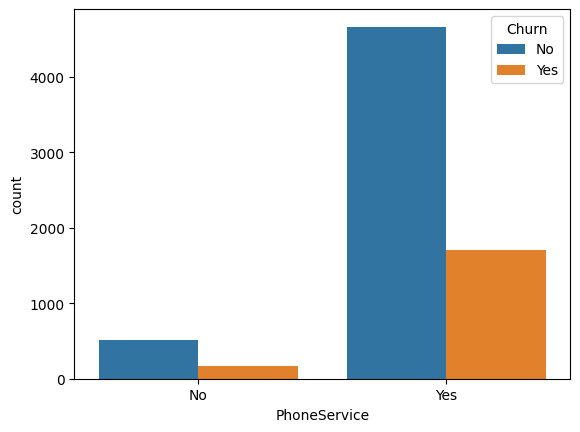

In [33]:
sns.countplot(x='PhoneService',hue='Churn', data=df)
plt.show()

MultipleLines

In [34]:
df['MultipleLines'].value_counts()

,count
MultipleLines,
No,3390
Yes,2971
No phone service,682


In [35]:
pd.crosstab(df['MultipleLines'],df['Churn'],normalize='index')*100
# may be one hot encoding

Churn,No,Yes
MultipleLines,,
No,74.955752,25.044248
No phone service,75.073314,24.926686
Yes,71.390104,28.609896


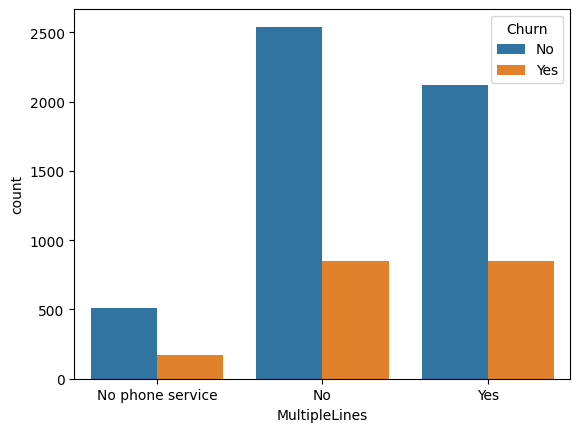

In [36]:
sns.countplot(x='MultipleLines',hue='Churn', data=df)
plt.show()

InternetService

In [37]:
df['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2421
No,1526


In [38]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index')*100
# useful feature

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


<Axes: xlabel='InternetService', ylabel='count'>

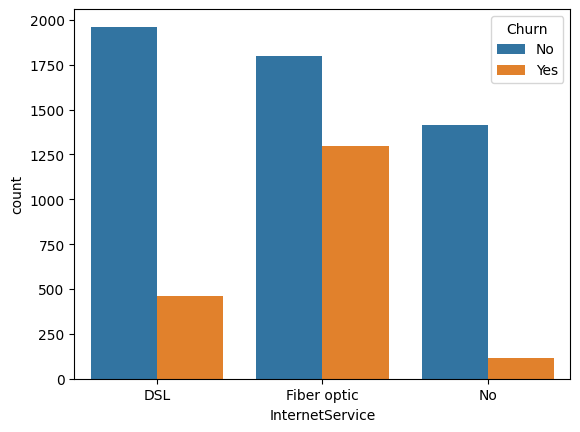

In [39]:
sns.countplot(data=df, x='InternetService', hue='Churn')
# Churn rates differ across internet service categories
# The category with the highest churn rate appears to
# be (Fiber optic), while (No) has the lowest churn rate.

TechSupport and OnlineSecurity

In [40]:
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index')*100
# useful feature

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [41]:
pd.crosstab(df['OnlineSecurity'], df['Churn'], normalize='index')*100
# useful feature

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


In [42]:
# Customers with different levels of TechSupport and OnlineSecurity
# show different churn rates. These features therefore appear to have
# an association with customer churn

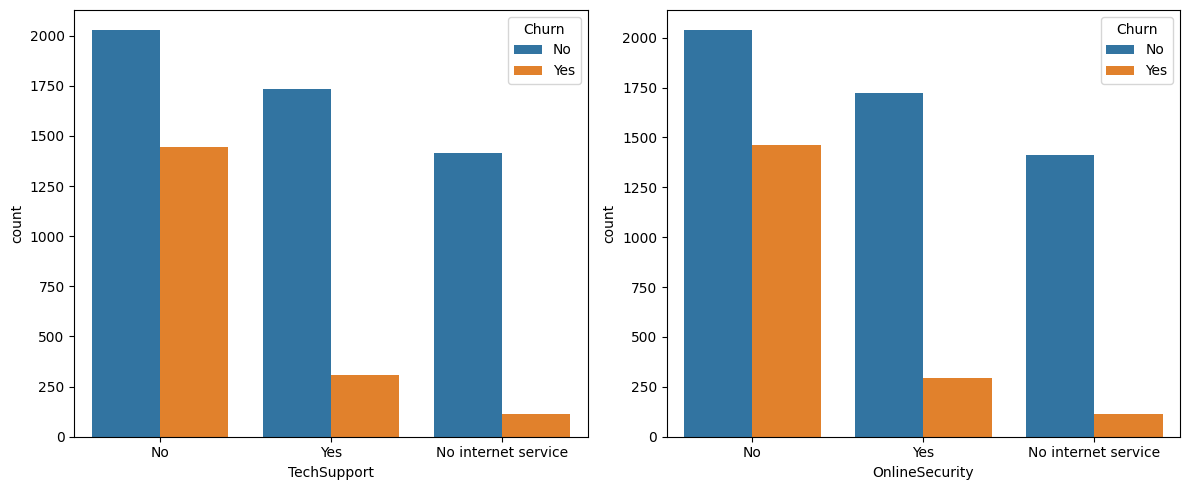

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='TechSupport', hue='Churn', ax=axes[0])

sns.countplot(data=df, x='OnlineSecurity', hue='Churn', ax=axes[1])

plt.tight_layout()
plt.show()

OnlineBackup

In [44]:
pd.crosstab(df['OnlineBackup'], df['Churn'], normalize='index')*100
# useful feature

Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


<Axes: xlabel='OnlineBackup', ylabel='count'>

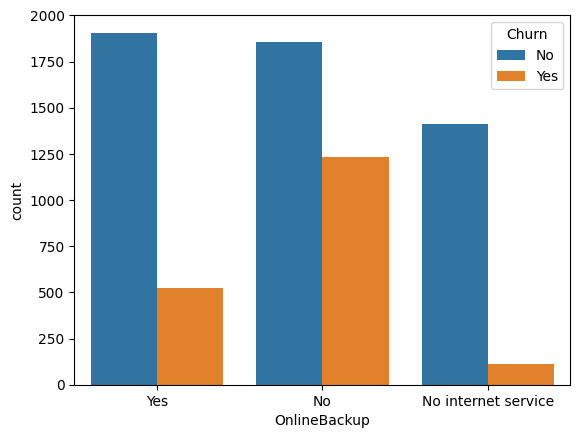

In [45]:
sns.countplot(data=df, x='OnlineBackup', hue='Churn')

DeviceProtection

In [46]:
pd.crosstab(df['DeviceProtection'], df['Churn'], normalize='index')*100
# useful feature

Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


<Axes: xlabel='DeviceProtection', ylabel='count'>

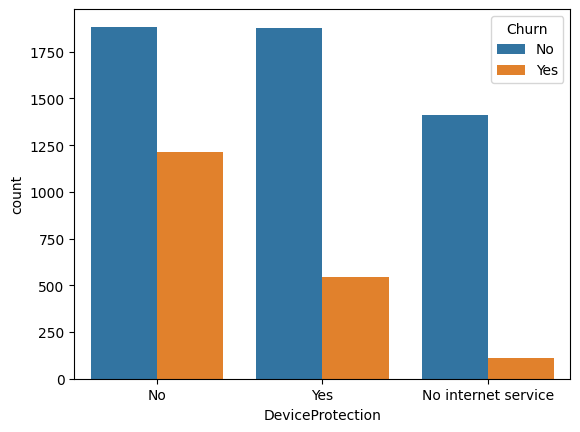

In [47]:
sns.countplot(data=df, x='DeviceProtection', hue='Churn')

TechSupport

In [48]:
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index')*100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


<Axes: xlabel='TechSupport', ylabel='count'>

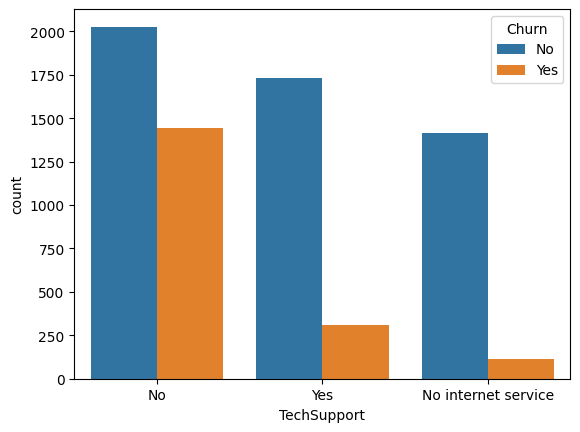

In [49]:
sns.countplot(data=df, x='TechSupport', hue='Churn')

StreamingTV

In [50]:
pd.crosstab(df['StreamingTV'], df['Churn'], normalize='index')*100

Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


<Axes: xlabel='TechSupport', ylabel='count'>

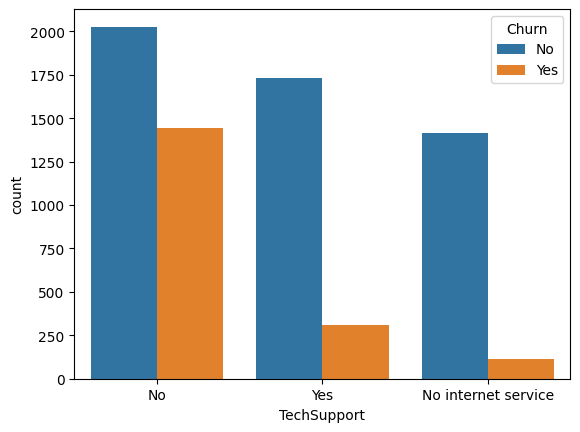

In [51]:
sns.countplot(data=df, x='TechSupport', hue='Churn')

StreamingMovies

In [52]:
pd.crosstab(df['StreamingMovies'], df['Churn'], normalize='index')*100
# useful

Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


<Axes: xlabel='StreamingMovies', ylabel='count'>

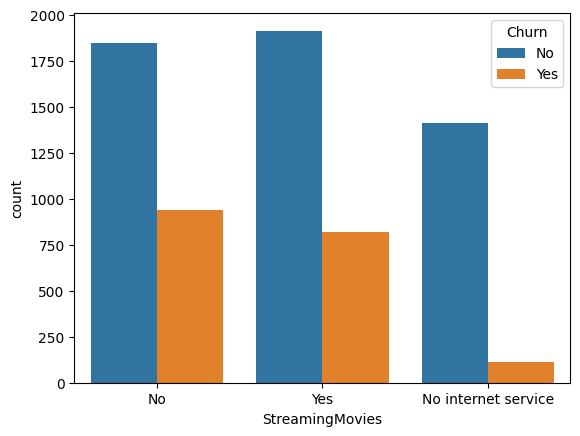

In [53]:
sns.countplot(data=df, x='StreamingMovies', hue='Churn')

Contract

In [54]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')*100
# useful

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [55]:
# Churn rate varies considerably across contract types.
# Month-to-month customers show a higher tendency to churn
# compared with customers on longer-term contracts.

PaperlessBilling

In [56]:
pd.crosstab(df['PaperlessBilling'], df['Churn'], normalize='index')*100
# useful

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


<Axes: xlabel='PaperlessBilling', ylabel='count'>

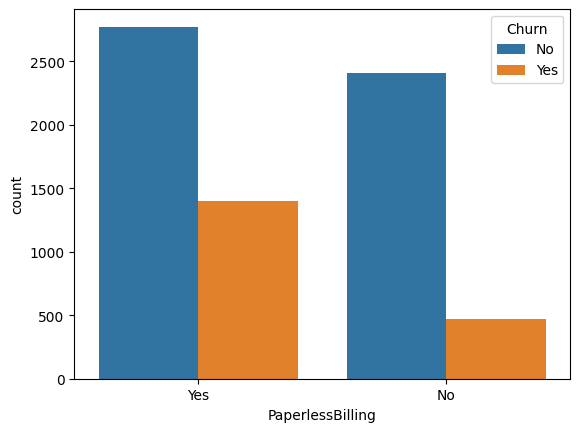

In [57]:
sns.countplot(data=df, x='PaperlessBilling', hue='Churn')

PaymentMethod

In [58]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')*100
# useful

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [59]:
# Churn rates differ across payment methods.
# The payment method with the highest churn rate is (Electronic check)
# while the lowest churn rate is (Credit card)

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

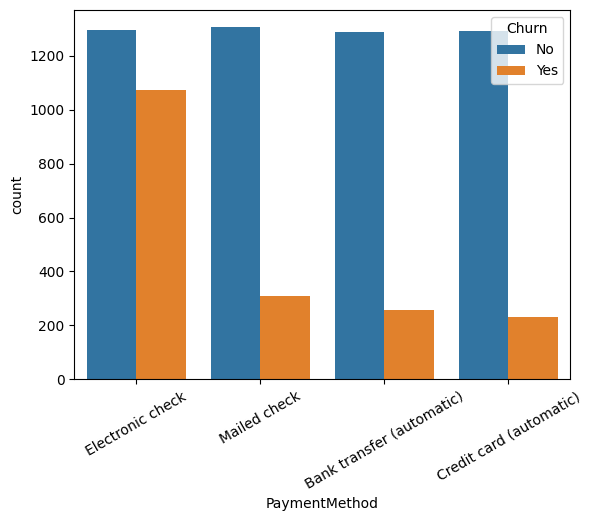

In [60]:
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.xticks(rotation=30)

SeniorCitizen

In [61]:
pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index')*100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


<Axes: xlabel='SeniorCitizen', ylabel='count'>

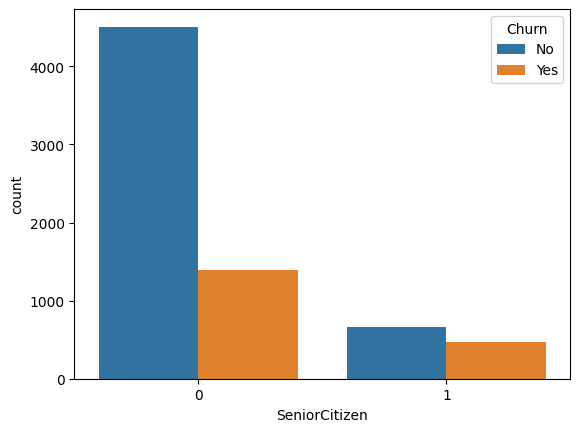

In [62]:
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

# Numeric Column

Tenure

<Axes: xlabel='Churn', ylabel='tenure'>

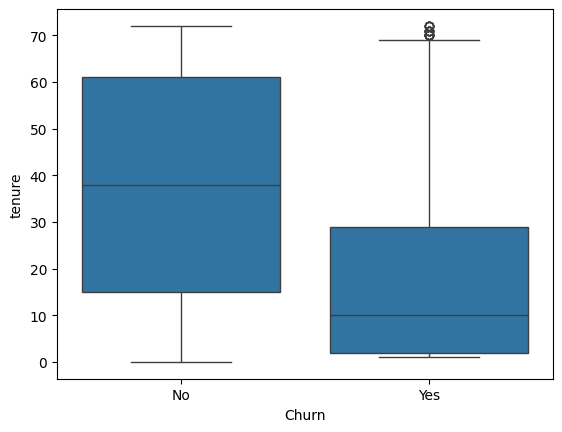

In [63]:
sns.boxplot(x='Churn', y='tenure', data=df)
# tenure is inversely proportional to churn

In [64]:
df.groupby('Churn')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


<Axes: xlabel='tenure', ylabel='Count'>

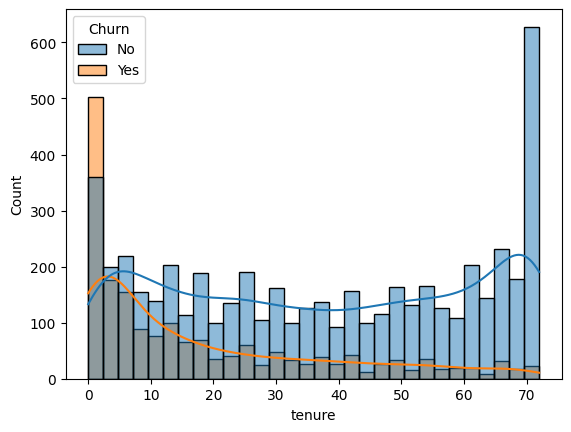

In [65]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)

MonthlyCharges

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

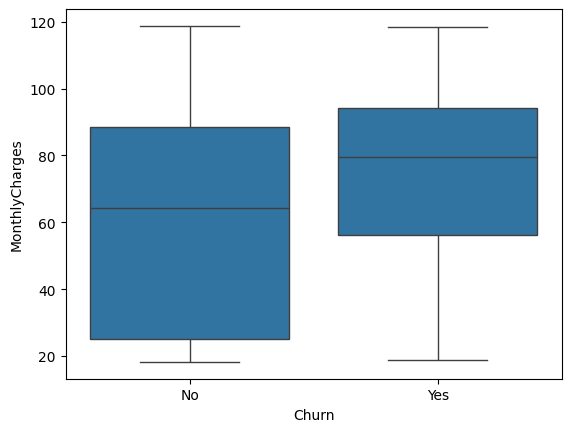

In [66]:
sns.boxplot(y=df['MonthlyCharges'], x=df['Churn'], data=df)

In [67]:
(df['MonthlyCharges'] == 0).sum()

np.int64(0)

In [68]:
df.groupby('Churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


<Axes: xlabel='MonthlyCharges', ylabel='Count'>

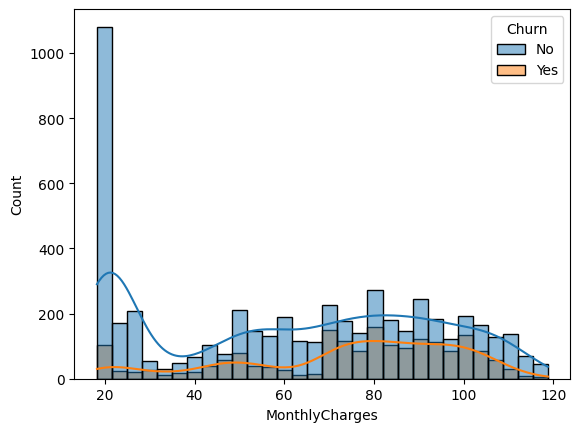

In [69]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True)

TotalCharges
* is present in form of category but it should be numerical column

In [70]:
df['TotalCharges'].value_counts()

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
...,...
130.15,1
3211.9,1
7843.55,1


In [71]:
# errors='coerce' tells Pandas:
# If you find a value that cannot be converted into a number, don't give an error ; convert it to (NaN) instead

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges']

,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.50
7039,7362.90
7040,346.45
7041,306.60


In [72]:
# null value is present
df['TotalCharges'].isna().sum()

np.int64(11)

In [73]:
df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [74]:
# The missing TotalCharges values are associated with customers whose tenure is 0.
# Their actual total charge is logically around 0, not the average total charge of all customers.

df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [75]:
df.groupby('Churn')['TotalCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


<Axes: xlabel='Churn', ylabel='TotalCharges'>

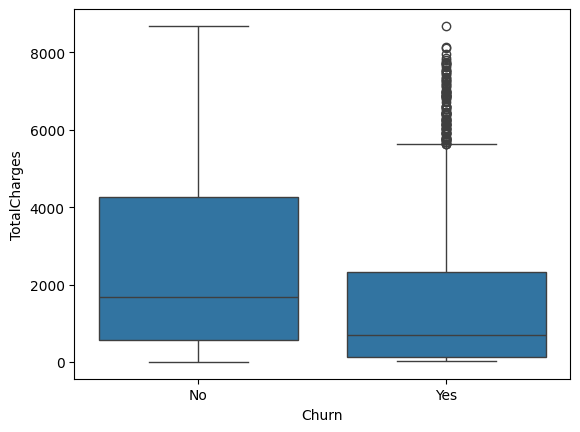

In [76]:
sns.boxplot(data=df,x='Churn',y='TotalCharges')

<Axes: xlabel='TotalCharges', ylabel='Count'>

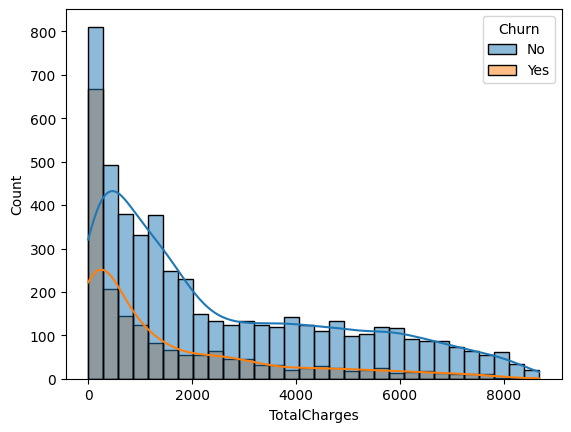

In [77]:
sns.histplot(data=df, x='TotalCharges', hue='Churn', bins=30,  kde=True)

# Correletion between numeric columns

<Axes: >

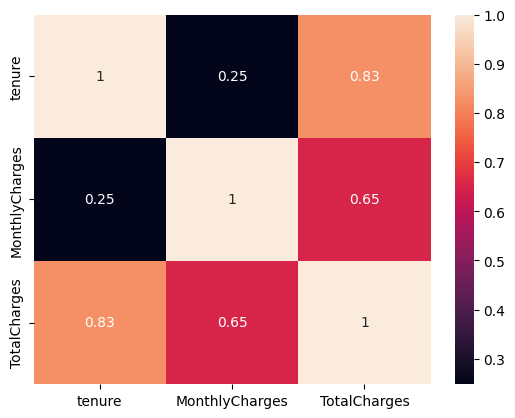

In [78]:
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True)

In [79]:
df.drop(columns=['customerID'],axis=1, inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [80]:
df = pd.get_dummies(columns=[
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines','InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection','TechSupport',
    'StreamingTV' ,'StreamingMovies', 'Contract' ,
    'PaperlessBilling', 'PaymentMethod'],
    data=df, drop_first=True, dtype=int)

In [81]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [82]:
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,1,1,1,1,0,...,0,1,0,1,1,0,1,0,0,1
7039,0,72,103.20,7362.90,0,0,1,1,1,0,...,0,1,0,1,1,0,1,1,0,0
7040,0,11,29.60,346.45,0,0,1,1,0,1,...,0,0,0,0,0,0,1,0,1,0
7041,1,4,74.40,306.60,1,1,1,0,1,0,...,0,0,0,0,0,0,1,0,0,1


X and y separation

In [83]:
X = df.drop(columns='Churn', axis=1)
y = df['Churn']

Train Test Split

In [84]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# fit → learns mean and standard deviation from training data
# transform → scales using those learned values.

6 baseline models → select top 3 by F1 → tune top 3 → evaluate → compare Base vs Tuned → select final model.

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,recall_score,f1_score, roc_auc_score, confusion_matrix,classification_report)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [87]:
# Baseline Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'NB': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'svm': SVC(),
    'DT': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier()
}

In [88]:
# Baseline F1
res = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    f1 = f1_score(y_test, y_pred)
    res[name] = f1

res

{'Logistic Regression': 0.6370157819225251,
 'NB': 0.5857519788918206,
 'KNN': 0.5457102672292545,
 'svm': 0.603030303030303,
 'DT': 0.4572192513368984,
 'Random Forest': 0.5559006211180124}

In [89]:
# Top 3 Models for Tuning
tune_model = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),

    'svm': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC())
    ]),

    'NB': GaussianNB()
}

In [90]:
# Parameter Grids
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100]
    },

    "svm": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    },

    "NB": {
        "var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
    }
}

In [91]:
# GridSearchCV
grids = {}

for name, model in tune_model.items():

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=3,
        scoring='f1',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    grids[name] = grid

In [92]:
# Best Model is Logistic
for name, grid in grids.items():
    print(name)
    print("Best CV F1:", grid.best_score_)
    print("Best Parameters:", grid.best_params_)
    print()

Logistic Regression
Best CV F1: 0.592699445495949
Best Parameters: {'model__C': 10}

svm
Best CV F1: 0.5849651412095903
Best Parameters: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}

NB
Best CV F1: 0.5844175202278792
Best Parameters: {'var_smoothing': 1e-07}



In [93]:
# Tuned Model Evaluation
tuned_results = []

for name, grid in grids.items():

    y_pred = grid.predict(X_test)

    tuned_results.append({
        "Model": name,
        "Tuned Accuracy": accuracy_score(y_test, y_pred),
        "Tuned Precision": precision_score(y_test, y_pred),
        "Tuned Recall": recall_score(y_test, y_pred),
        "Tuned F1": f1_score(y_test, y_pred)
    })

tuned_result = pd.DataFrame(tuned_results)

tuned_result

,Model,Tuned Accuracy,Tuned Precision,Tuned Recall,Tuned F1
0,Logistic Regression,0.818311,0.680000,0.592493,0.633238
1,svm,0.820440,0.686335,0.592493,0.635971
2,NB,0.725337,0.489028,0.836461,0.617211


In [94]:
# Confusion Matrix and Classification Report
for name, grid in grids.items():

    y_pred = grid.predict(X_test)

    print("=" * 50)
    print(name)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Logistic Regression

Confusion Matrix:
[[932 104]
 [152 221]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.59      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.81      1409

svm

Confusion Matrix:
[[935 101]
 [152 221]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.59      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

NB

Confusion Matrix:
[[710 326]
 [ 61 312]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.69      0.79      1036
           1

In [95]:
#  ROC-AUC
for name, grid in grids.items():

    if hasattr(grid.best_estimator_, "predict_proba"):
        y_score = grid.predict_proba(X_test)[:, 1]
    else:
        y_score = grid.decision_function(X_test)

    print(name)
    print("ROC-AUC:", roc_auc_score(y_test, y_score))
    print()

Logistic Regression
ROC-AUC: 0.8618643058991584

svm
ROC-AUC: 0.8526879522187835

NB
ROC-AUC: 0.8409263821462212



In [96]:
# Base Result Table
base_result = pd.DataFrame(
    list(res.items()),
    columns=['Model', 'Base F1']
)

base_result

,Model,Base F1
0,Logistic Regression,0.637016
1,NB,0.585752
2,KNN,0.545710
3,svm,0.603030
4,DT,0.457219
5,Random Forest,0.555901


In [97]:
# Base vs Tuned Comparison
comparison = pd.merge(
    base_result,
    tuned_result,
    on='Model',
    how='inner'
)

comparison

,Model,Base F1,Tuned Accuracy,Tuned Precision,Tuned Recall,Tuned F1
0,Logistic Regression,0.637016,0.818311,0.680000,0.592493,0.633238
1,NB,0.585752,0.725337,0.489028,0.836461,0.617211
2,svm,0.603030,0.820440,0.686335,0.592493,0.635971


In [98]:
# F1 Improvement
comparison['F1 Improvement'] = (
    comparison['Tuned F1'] - comparison['Base F1']
)

comparison

,Model,Base F1,Tuned Accuracy,Tuned Precision,Tuned Recall,Tuned F1,F1 Improvement
0,Logistic Regression,0.637016,0.818311,0.680000,0.592493,0.633238,-0.003778
1,NB,0.585752,0.725337,0.489028,0.836461,0.617211,0.031459
2,svm,0.603030,0.820440,0.686335,0.592493,0.635971,0.032941


In [99]:
comparison.sort_values(
    by='Tuned F1',
    ascending=False
)

,Model,Base F1,Tuned Accuracy,Tuned Precision,Tuned Recall,Tuned F1,F1 Improvement
2,svm,0.603030,0.820440,0.686335,0.592493,0.635971,0.032941
0,Logistic Regression,0.637016,0.818311,0.680000,0.592493,0.633238,-0.003778
1,NB,0.585752,0.725337,0.489028,0.836461,0.617211,0.031459


In [100]:
# Final Model

best_model_name = max(
    grids,
    key=lambda name: grids[name].best_score_
)

best_model = grids[best_model_name]

y_pred = best_model.predict(X_test)

print("Best Model:", best_model_name)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 932 → correctly predicted non-churn
# 104 → predicted churn but actually non-churn
# 152 → actual churn but predicted non-churn
# 221 → correctly predicted churn

Best Model: Logistic Regression
Accuracy : 0.8183108587650816
Precision: 0.68
Recall   : 0.5924932975871313
F1 Score : 0.6332378223495702
[[932 104]
 [152 221]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.59      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.81      1409



Permutation Importance = feature ko randomly shuffle karke dekhna ki model ki performance kitni girti hai.

F1 bahut girta hai → feature important hai.
F1 almost same rahta hai → feature less important hai.

Final model ke liye permutation importance use kar rahe hain

Feature shuffle → Model predict → F1 compare → Importance rank

In [101]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring='f1',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm.importances_mean
}).sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,tenure,0.265882
10,InternetService_Fiber optic,0.207542
2,MonthlyCharges,0.092700
25,Contract_Two year,0.091636
21,StreamingTV_Yes,0.042471
23,StreamingMovies_Yes,0.036291
24,Contract_One year,0.030496
3,TotalCharges,0.025822
26,PaperlessBilling_Yes,0.025665
28,PaymentMethod_Electronic check,0.021950


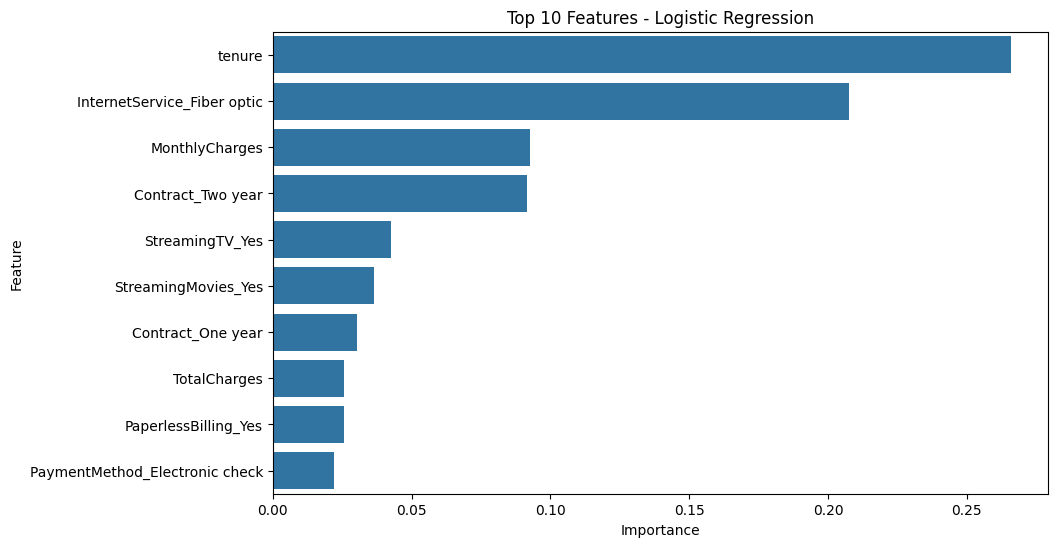

In [102]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title(f'Top 10 Features - {best_model_name}')
plt.show()

In [103]:
# Final Model Summary

print("Final Model:", best_model_name)
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_score), 4))

Final Model: Logistic Regression
Accuracy : 0.8183
Precision: 0.68
Recall   : 0.5925
F1 Score : 0.6332
ROC-AUC  : 0.8409


In [104]:
## Final Conclusion

# - Logistic Regression was selected as the final model based on the highest cross-validation F1 score.
# - The final model achieved an F1 score of approximately 0.633 on the test set.
# - The model achieved a recall of approximately 0.592, meaning it identified around 59% of actual churn customers.
# - The confusion matrix shows both correctly and incorrectly classified churn and non-churn customers.
# - Permutation importance was used to identify the features that had the greatest impact on model performance.
# - Features such as tenure, TotalCharges, MonthlyCharges, and InternetService were among the important predictors.

In [106]:
import joblib

joblib.dump(models[best_model_name], "Churn_Prediction_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']